Zadanie 16 -- Wplyw batch_size
Zbadaj wplyw rozmiaru mini-batcha na trening MLP.
Wymagania:<br>
Dataset: Breast Cancer<br>
batch_size: 16, 32, 64, 128, 256, 'auto'<br>
Architektura: (64, 32), solver='adam', max_iter=300<br>
Dla kazdego: accuracy, czas treningu, losscurve<br>
Narysuj loss_curves na jednym wykresie<br>
Analiza: mniejszy batch = szumniejszy trening, wiekszy = gladszy<br>
Oczekiwany wynik:<br>
Wykres z 6 krzywymi uczenia i porownanie<br>


Trening MLP z batch_size=16
Accuracy: 0.9649, Czas treningu: 0.89s

Trening MLP z batch_size=32
Accuracy: 0.9737, Czas treningu: 0.63s

Trening MLP z batch_size=64
Accuracy: 0.9649, Czas treningu: 0.59s

Trening MLP z batch_size=128
Accuracy: 0.9649, Czas treningu: 0.41s

Trening MLP z batch_size=256
Accuracy: 0.9649, Czas treningu: 0.41s

Trening MLP z batch_size=auto
Accuracy: 0.9649, Czas treningu: 0.43s


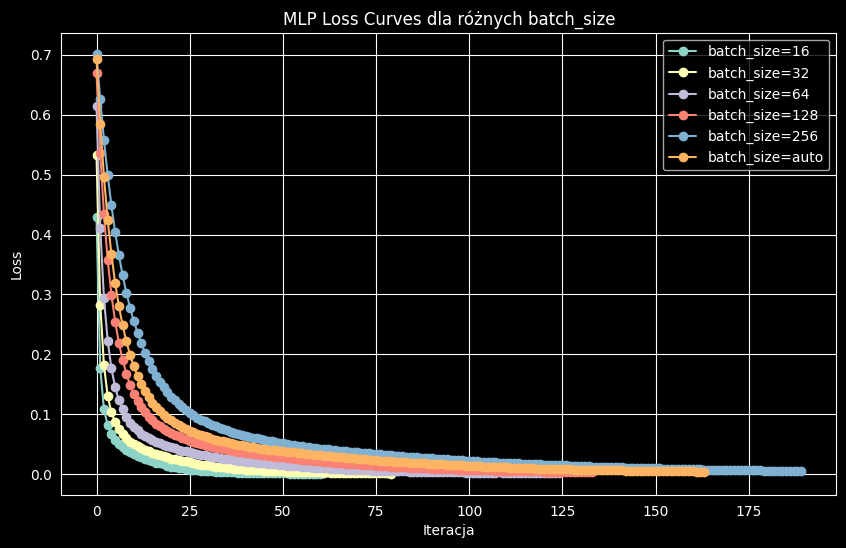

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X = data.data
y = data.target

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standaryzacja cech (średnia 0, std 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Lista batch_size do testów
batch_sizes = [16, 32, 64, 128, 256, 'auto']

# Słowniki do przechowywania wyników
loss_curves = {}
accuracies = {}
training_times = {}

# Pętla po batch_size
for batch in batch_sizes:
    print(f"\nTrening MLP z batch_size={batch}")

    # Tworzymy MLP
    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        solver='adam',
        batch_size=batch,
        max_iter=300,  # zgodnie z treścią zadania
        random_state=42,
        early_stopping=False  # wyłączamy early stopping, żeby porównać batch_size
    )

    # Pomiar czasu treningu
    start_time = time.time()
    mlp.fit(X_train_scaled, y_train)
    end_time = time.time()

    # Zapis czasu treningu
    training_times[batch] = end_time - start_time

    # Predykcje na zbiorze testowym
    y_pred = mlp.predict(X_test_scaled)

    # Dokładność
    accuracies[batch] = accuracy_score(y_test, y_pred)

    # Loss curve
    loss_curves[batch] = mlp.loss_curve_

    print(f"Accuracy: {accuracies[batch]:.4f}, Czas treningu: {training_times[batch]:.2f}s")


# Rysowanie krzywych uczenia
plt.figure(figsize=(10, 6))
for batch in batch_sizes:
    plt.plot(loss_curves[batch], marker='o', label=f'batch_size={batch}')
plt.title("MLP Loss Curves dla różnych batch_size")
plt.xlabel("Iteracja")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()
